In [2]:
pip install tensorflow opencv-python matplotlib seaborn scikit-learn streamlit

Note: you may need to restart the kernel to use updated packages.


In [26]:
!pip install -q tensorflow opencv-python matplotlib scikit-learn

import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

In [27]:
DATASET_PATH = "/kaggle/input/datasets/athirarag/sugarcane"

In [28]:
img_size = (224,224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

class_names = list(train_data.class_indices.keys())
print("Classes:", class_names)

Found 2019 images belonging to 5 classes.
Found 502 images belonging to 5 classes.
Classes: ['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow']


In [29]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5


2026-03-22 16:06:22.092346: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 16:06:22.229994: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


13/64 ━━━━━━━━━━━━━━━━━━━━ 12s 243ms/step - accuracy: 0.4057 - loss: 1.5956

2026-03-22 16:06:35.526586: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 16:06:35.662707: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.5787 - loss: 1.1240

2026-03-22 16:07:07.829610: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 16:07:07.966675: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 722ms/step - accuracy: 0.5806 - loss: 1.1192 - val_accuracy: 0.6096 - val_loss: 0.9904
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 334ms/step - accuracy: 0.8695 - loss: 0.3762 - val_accuracy: 0.7291 - val_loss: 0.7197
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 334ms/step - accuracy: 0.9165 - loss: 0.2680 - val_accuracy: 0.7371 - val_loss: 0.7246
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 322ms/step - accuracy: 0.9405 - loss: 0.2030 - val_accuracy: 0.7251 - val_loss: 0.7698
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 327ms/step - accuracy: 0.9727 - loss: 0.1313 - val_accuracy: 0.7032 - val_loss: 0.8651


In [31]:
val_data.reset()
preds = model.predict(val_data)
y_pred = np.argmax(preds, axis=1)

print(classification_report(val_data.classes, y_pred, target_names=class_names))

16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 519ms/step
              precision    recall  f1-score   support

     Healthy       0.24      0.23      0.23       104
      Mosaic       0.20      0.12      0.15        92
      RedRot       0.15      0.13      0.14       103
        Rust       0.19      0.15      0.16       102
      Yellow       0.21      0.38      0.27       101

    accuracy                           0.20       502
   macro avg       0.20      0.20      0.19       502
weighted avg       0.20      0.20      0.19       502



In [32]:
val_data.reset()
preds = model.predict(val_data)
y_pred = np.argmax(preds, axis=1)

print(classification_report(val_data.classes, y_pred, target_names=class_names))

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step
              precision    recall  f1-score   support

     Healthy       0.19      0.18      0.19       104
      Mosaic       0.24      0.14      0.18        92
      RedRot       0.22      0.19      0.21       103
        Rust       0.19      0.15      0.16       102
      Yellow       0.18      0.32      0.23       101

    accuracy                           0.20       502
   macro avg       0.20      0.20      0.19       502
weighted avg       0.20      0.20      0.19       502



In [33]:
model.save("/kaggle/working/sugarcane_model.h5")

In [34]:
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer

In [35]:
def predict_and_explain(img_path):

    img = cv2.imread(img_path)
    if img is None:
        print("Image not found")
        return

    img = cv2.resize(img, (224,224))
    img_norm = img / 255.0
    img_array = np.expand_dims(img_norm, axis=0)

    preds = model.predict(img_array, verbose=0)
    class_id = np.argmax(preds)
    confidence = preds[0][class_id]

    print("Prediction:", class_names[class_id])
    print("Confidence:", round(confidence*100,2), "%")

    last_conv_layer = get_last_conv_layer(model)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_id]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    heatmap = heatmap.numpy()

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.show()

2026-03-22 16:10:53.341215: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 16:10:53.475352: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Prediction: Yellow
Confidence: 82.3 %


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_67']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


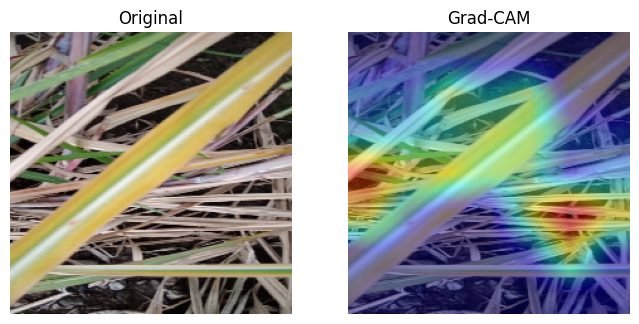

In [36]:
img_path = "/kaggle/input/datasets/athirarag/sugarcane/Yellow/yellow (94).jpeg"
predict_and_explain(img_path)

In [37]:
loss, acc = model.evaluate(val_data)
print("Accuracy:", acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 334ms/step - accuracy: 0.7158 - loss: 0.7920
Accuracy: 0.7031872272491455
